# SVM classifier
> diabetes.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from mlxtend.plotting import plot_decision_regions
from sklearn.decomposition import PCA

In [10]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
# features and target
x = df.iloc[:, 0:-1]
y = df.iloc[:, -1]

# data split 
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42, stratify=y)

In [12]:
# correlation
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [13]:
# feature scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [14]:
# finding best kernel

kernels = ['poly','sigmoid','rbf']

for i in kernels:
    svc = SVC(kernel=i, probability=True, random_state=42)
    svc.fit(x_train, y_train)
    y_pred = svc.predict(x_test)
    
    print(i)
    print('accuracy_score:', accuracy_score(y_test, y_pred))
    print('cross_val_score:',cross_val_score(svc,scaler.transform(x), y, cv = 5, scoring='accuracy').mean())
    print(50*'--')

poly
accuracy_score: 0.7532467532467533
cross_val_score: 0.7500127323656736
----------------------------------------------------------------------------------------------------
sigmoid
accuracy_score: 0.7077922077922078
cross_val_score: 0.7070961718020542
----------------------------------------------------------------------------------------------------
rbf
accuracy_score: 0.7532467532467533
cross_val_score: 0.7708938120702827
----------------------------------------------------------------------------------------------------


> Hence we will use kernel as <span style = 'color:orange'>**'rbf'**</span>

✅ accuracy %: 75.32467532467533


              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154





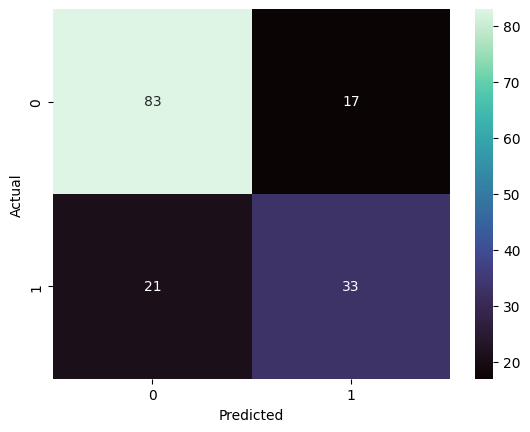

In [18]:
# model train
SVM = SVC(kernel='rbf',probability=True, random_state=42)
SVM.fit(x_train, y_train)
y_Pred = SVM.predict(x_test)

print('✅ accuracy %:', accuracy_score(y_test, y_Pred) * 100)
print('\n')
print(classification_report(y_test, y_Pred))
print('\n')
sns.heatmap(confusion_matrix(y_test, y_Pred), annot=True, cmap = 'mako')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


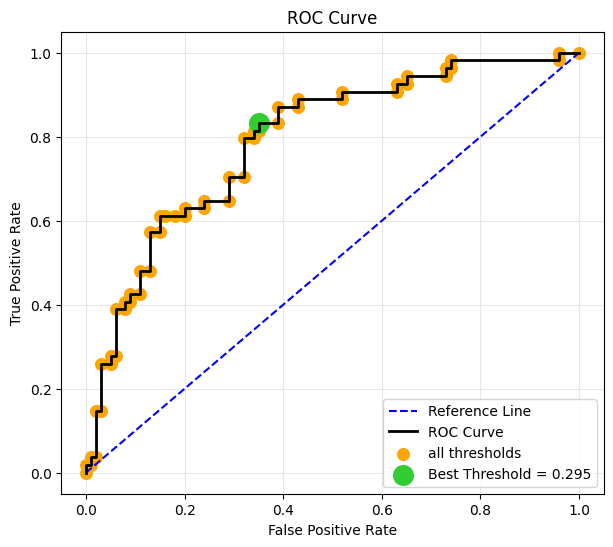

AUC Score: 0.7924074074074074


In [25]:
# ROC Curve

y_score = SVM.predict_proba(x_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_score)

# Best threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

plt.figure(figsize=(7,6))

plt.plot([0,1], [0,1], '--', color='blue', label='Reference Line')
plt.plot(fpr, tpr, color='black', linewidth=2, label='ROC Curve')
plt.scatter(fpr, tpr, color = 'orange', s = 70, label = 'all thresholds')
plt.scatter(
    fpr[optimal_idx],
    tpr[optimal_idx],
    color='limegreen',
    s=200,
    label=f'Best Threshold = {optimal_threshold:.3f}'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print("AUC Score:", roc_auc_score(y_test, y_score))

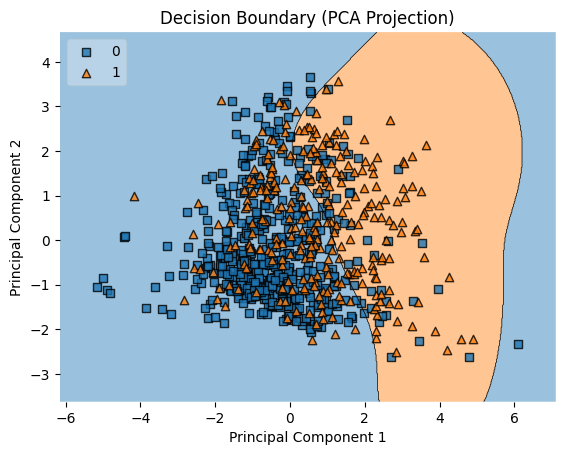

In [26]:
# decision boundry using PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(scaler.transform(x))

svm_pca = SVC(kernel='rbf', random_state=42)
svm_pca.fit(x_pca, y)

plot_decision_regions(x_pca,y.to_numpy(),clf=svm_pca,legend=2)
plt.title("Decision Boundary (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()